# 

This notebook demonstrates a simple linear regression analysis using [R] to model Salary based on Years of Experience.

Read the dataset

In [57]:
dataset <- read.csv("regression_data-1.csv")

Create a scatter plot

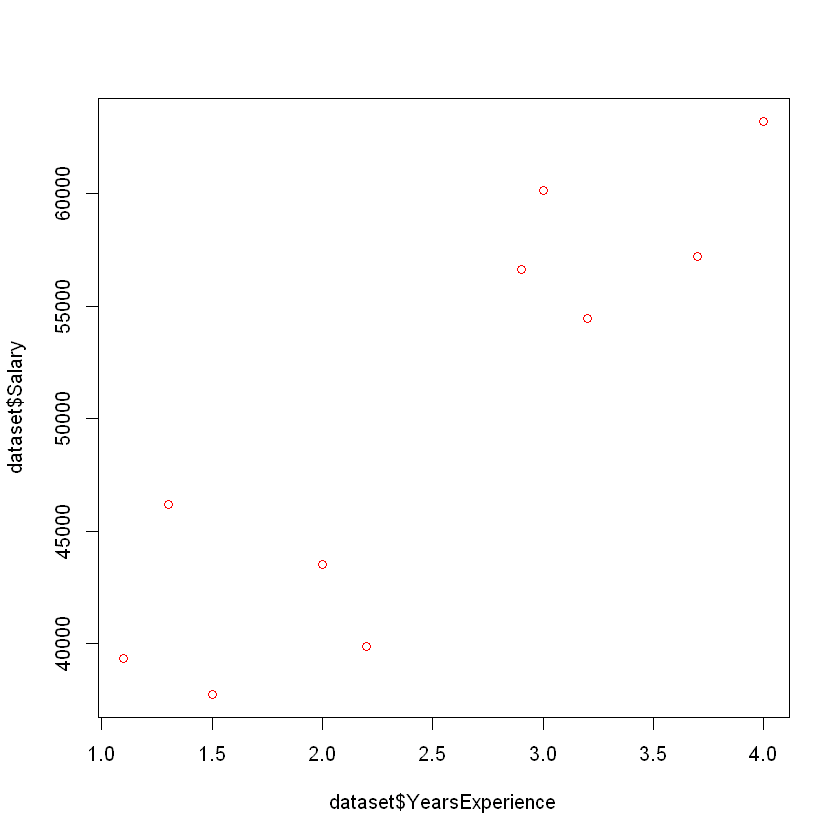

In [58]:
plot(dataset$YearsExperience, dataset$Salary, col="red")

Fit a linear model

In [59]:
model <- lm(Salary ~ YearsExperience, data=dataset)
r_squared <- summary(model)$r.squared
r <- cor(dataset$YearsExperience, dataset$Salary)
pred <- predict(model)
mse <- mean((dataset$Salary - pred)^2)
slope <- coef(model)[2]
intercept <- coef(model)[1]

Overlay the regression line

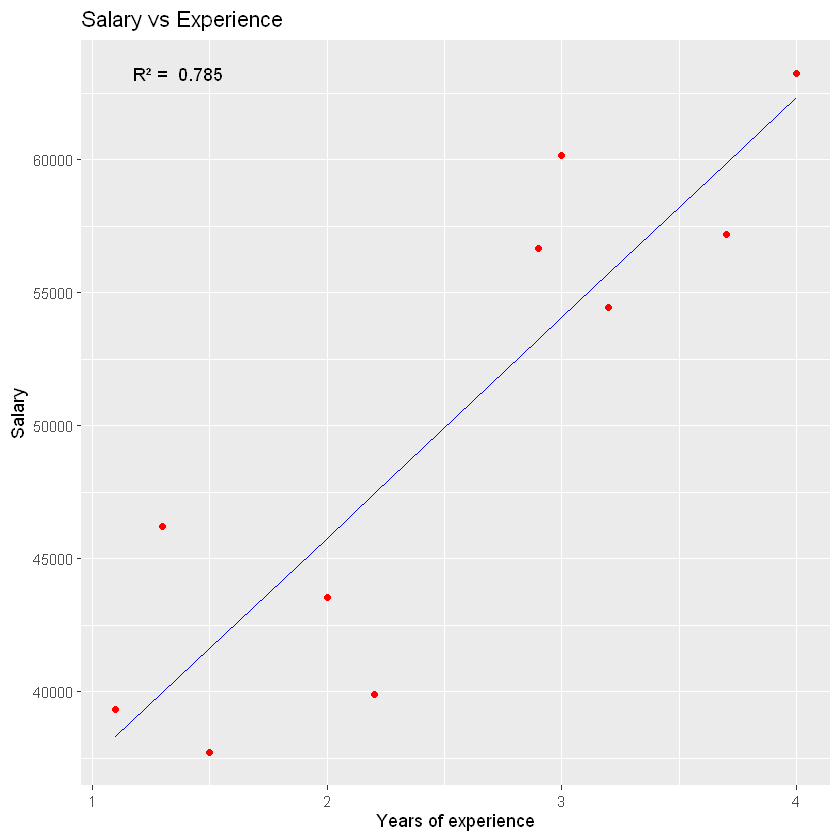

In [60]:
library(ggplot2)
ggplot() +
  geom_point(aes(x = dataset$YearsExperience, y = dataset$Salary), colour = 'red') +
  geom_line(aes(x = dataset$YearsExperience, y = predict(model, newdata = dataset)), colour = 'blue') +
annotate("text", x = min(dataset$YearsExperience), y = max(dataset$Salary), label = paste("R² = ", round(r_squared, 3)), hjust = -0.2) +
ggtitle('Salary vs Experience') +
  xlab('Years of experience') +
  ylab('Salary')

Annotating the graph

`geom_smooth()` using formula = 'y ~ x'


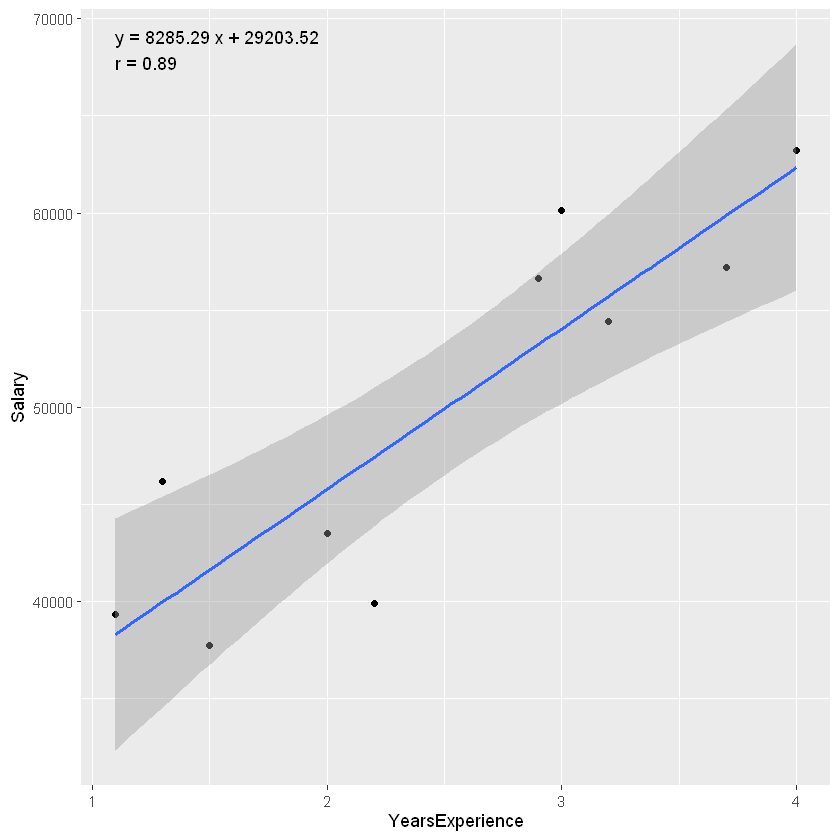

In [61]:
ggplot(dataset, aes(YearsExperience, Salary)) +
  geom_point() +
  geom_smooth(method='lm') +
  annotate("text", x=min(dataset$YearsExperience), y=max(dataset$Salary), label=paste("y =", round(slope, 2), "x +", round(intercept, 2), "\nr =", round(r, 2)), hjust=0, vjust=-2)

Creating a summary table

In [62]:
summary_table <- data.frame(Metric = c("Intercept", "Slope", "MSE", "r", "R_squared"), Value = c(intercept, slope, mse, r, r_squared))
summary_table

Metric,Value
<chr>,<dbl>
Intercept,2.920352e+04
Slope,8.285292e+03
MSE,1.752384e+07
r,8.860878e-01
R_squared,7.851516e-01
